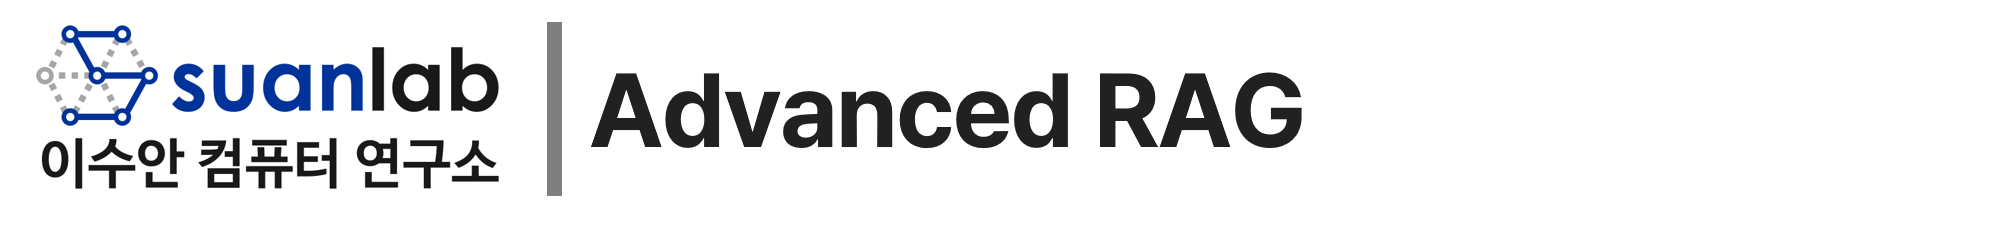

# 🔀 Hybrid 검색 & 쿼리 재작성·HyDE

## 환경 셋업 (맨 처음 한 번만 실행)

In [1]:
# === 환경 셋업 — 이 통합 노트북에서 "한 번만" 실행하면 전체 파트에서 그대로 씁니다 ===
# 비-Claude 라이브러리는 검색·그래프 인프라용입니다(Claude는 임베딩·BM25·리랭크·그래프 미제공).
!pip install -q "anthropic>=0.40" rank_bm25 faiss-cpu sentence-transformers matplotlib

import os, getpass, json, re, math, random, collections, textwrap
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Anthropic API Key: ")
from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # 정확도가 중요한 judge·추출 단계는 "claude-opus-4-8"로 상향 가능
print("환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 45.4 MB/s eta 0:00:00
Anthropic API Key: ··········
환경 셋업 완료 — API 키 입력됨, client·MODEL 준비됨


In [2]:
# 한글 폰트 설정 (Colab 환경)
!apt-get install -y fonts-nanum > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


---
# Sparse(BM25) + Dense Hybrid 검색 (RRF 융합)

## 학습목표
- dense(FAISS)와 sparse(BM25)를 각각 검색하고 **RRF**로 융합
- dense-only / BM25-only / Hybrid를 동일 쿼리셋(키워드형+의미형)으로 비교

## 사전개념
- **Dense**: 의미 유사도. 동의어/패러프레이즈에 강하나 정확한 키워드/희귀어에 약함
- **Sparse(BM25)**: 정확한 단어 매칭. 키워드/고유명사에 강함
- **RRF(Reciprocal Rank Fusion)**: 각 랭킹의 순위 역수를 합산. 점수 스케일 차이에 강건

> "의미와 키워드는 다른 실패를 함. Hybrid는 두 강점의 합집합"  
> 비-Claude: rank_bm25(sparse 랭킹, Claude 미제공), faiss/sentence-transformers(dense)

## 용어 미니 사전 (Hybrid 검색 편)
- 검색에는 두 종류가 있음
- **의미로 찾기(dense)**와 **단어로 찾기(sparse)**. 둘을 합치면 더 강함

| 용어 | 한 줄 뜻 |
|---|---|
| **Dense 검색** | 임베딩(의미 숫자)으로 *뜻이 비슷한* 문서 찾기. 동의어·말바꿈에 강함 |
| **Sparse 검색** | *정확한 단어 일치*로 찾기. 고유명사·숫자에 강함 |
| **BM25** | 대표적인 sparse(단어 매칭) 점수 계산 방식 |
| **토크나이징(tokenize)** | 문장을 단어 토막으로 쪼개는 것(BM25는 이게 필요) |
| **Hybrid 검색** | dense와 sparse 결과를 *합쳐서* 둘의 강점을 모두 쓰는 것 |
| **RRF** | 두 검색의 *순위*를 합산해 융합하는 방법(점수 단위가 달라도 OK) |
| **rrf_k** | RRF의 조절 상수. 작으면 1등에 민감, 크면 순위 차이를 완만하게 봄 |

> 핵심 메시지: **의미 검색과 단어 검색은 서로 다른 실수를 함**  
Hybrid는 한쪽이 놓친 정답을 다른 쪽이 건짐


## 코퍼스 + 두 인덱스
- 고유명사/숫자(키워드형)와 개념(의미형)이 섞인 코퍼스 구성

### 두 검색기 재료 준비(의미용·단어용)
- 같은 문서들에 대해 **두 개의 검색 색인**을 만들기
- 의미용(임베딩+FAISS)과 단어용(BM25). BM25는 문장을 단어로 쪼갠 목록이 필요해 `d.split()`으로 토막 냄(한국어 공백 분리는 거칠지만 실습엔 충분)

In [3]:
import numpy as np, faiss, math
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

DOCS = [
    "노바테크의 2023년 매출은 1조 2천억 원이다.",
    "노바테크 CEO 김하늘은 AI 가속기 사업을 확장했다.",
    "그린모빌리티는 리튬인산철 배터리를 만드는 전기차 부품 회사다.",
    "오션로지스틱스는 친환경 연료 선박으로 탄소배출을 줄였다.",
    "퀀텀칩은 데이터센터용 AI 칩 시장에서 노바테크와 경쟁한다.",
    "정밀소재(PrecisionMat)는 노바테크와 퀀텀칩의 공통 공급사다.",
    "노바소프트는 노바테크의 클라우드 소프트웨어 자회사다.",
    "그린모빌리티 CFO 박서준은 2024년 IPO를 준비 중이다.",
]
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
def embed(t): return np.array(embedder.encode(t, normalize_embeddings=True), dtype="float32")
DOC_EMB = embed(DOCS)
findex = faiss.IndexFlatIP(DOC_EMB.shape[1]); findex.add(DOC_EMB)

# BM25는 토큰 리스트가 필요. 한국어는 공백 토크나이징이 거칠다(확장과제에서 다룸).
tokenized = [d.split() for d in DOCS]
bm25 = BM25Okapi(tokenized)
print("dense + BM25 인덱스 준비 완료")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

dense + BM25 인덱스 준비 완료


## 각 검색기 (랭킹 id 반환)

### 두 방식으로 각각 검색해 보기
- `dense_rank`는 의미로, `bm25_rank`는 단어로 상위 문서 번호를 뽑기
- **출력 읽는 법**: '배터리 만드는 회사'(말바꿈)는 의미검색이, '리튬인산철'(정확한 단어)은 단어검색이 잘 맞히는 경향을 보기


In [4]:
def dense_rank(query, k=8):
    q = embed([query]); _, idx = findex.search(q, min(k, len(DOCS)))
    return list(idx[0])

def bm25_rank(query, k=8):
    scores = bm25.get_scores(query.split())
    order = list(np.argsort(scores)[::-1][:k])
    return [int(i) for i in order]

print("dense:", dense_rank("배터리 만드는 회사"))
print("bm25 :", bm25_rank("리튬인산철"))

dense: [np.int64(2), np.int64(5), np.int64(4), np.int64(3), np.int64(0), np.int64(1), np.int64(6), np.int64(7)]
bm25 : [2, 7, 5, 6, 4, 3, 1, 0]


## RRF 융합 함수
$$\text{score}(d) = \sum \frac{1}{\text{rrf}_k + \text{rank_in_list}}$$
- rank는 1부터

### 두 결과를 RRF로 합치기
- 두 검색의 **순위**를 더해(순위 역수 합산) 하나의 융합 순위를 만듦
- 점수 단위가 달라도 순위만 쓰므로 안전함
- 맨 아래 단위 테스트는 "두 검색 모두 1등인 문서가 융합 후에도 1등인가"를 확인함
- `통과`면 정상


In [5]:
def rrf_fuse(rankings, rrf_k=60, top=8):
    # rankings: list of ranked id-lists. 반환: 융합 점수 내림차순 id 리스트.
    scores = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, start=1):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)
    ordered = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_id for doc_id, _ in ordered[:top]], dict(ordered)

def hybrid_rank(query, k=8, rrf_k=60):
    d = dense_rank(query, k); b = bm25_rank(query, k)
    fused, _ = rrf_fuse([d, b], rrf_k=rrf_k, top=k)
    return fused

# 단위 테스트: 두 리스트 모두 1위인 문서가 최상위
fused, sc = rrf_fuse([[3, 1, 2], [3, 2, 1]], rrf_k=60, top=3)
assert fused[0] == 3, "두 랭킹 공통 1위가 최상위여야 함"
assert sc[3] > sc[1], "공통 상위 문서 점수가 더 높아야 함"
print("RRF 단위테스트 통과:", fused)

RRF 단위테스트 통과: [3, 1, 2]


## 평가셋으로 세 방식 비교
- 키워드형(고유명사/숫자)과 의미형(개념) 쿼리를 섞음

### 세 방식 성적 비교(키워드형+의미형 섞어)
- 정답이 정해진 질문 5개로 **dense / BM25 / Hybrid** 의 Hit@5·nDCG@5를 측정
- 질문은 단어형과 의미형을 섞음
- **출력 읽는 법**: 보통 **Hybrid가 두 단일 방식보다 같거나 높게** 나옴 (둘의 강점을 합쳤으니까)


In [6]:
EVALSET = [
    {"q": "리튬인산철", "gold": 2},               # 키워드형 (정확한 단어)
    {"q": "PrecisionMat", "gold": 5},             # 키워드형 (고유명사)
    {"q": "배터리 만드는 회사", "gold": 2},        # 의미형 (패러프레이즈)
    {"q": "탄소를 줄인 물류 기업", "gold": 3},      # 의미형
    {"q": "IPO 준비하는 임원", "gold": 7},          # 의미형 + 일부 키워드
]

def hit_at_k(ranked, gold, k): return 1.0 if gold in ranked[:k] else 0.0
def ndcg_at_k(ranked, gold, k):
    dcg = sum((1.0 if d == gold else 0.0)/math.log2(r+1) for r, d in enumerate(ranked[:k], 1))
    return dcg / (1.0/math.log2(2))

def evaluate(rank_fn, k=5):
    hits = [hit_at_k(rank_fn(e["q"], k), e["gold"], k) for e in EVALSET]
    ndcgs = [ndcg_at_k(rank_fn(e["q"], k), e["gold"], k) for e in EVALSET]
    return sum(hits)/len(hits), sum(ndcgs)/len(ndcgs)

for name, fn in [("dense", dense_rank), ("bm25", bm25_rank), ("hybrid", hybrid_rank)]:
    h, n = evaluate(fn, k=5)
    print(f"{name:7s}  Hit@5={h:.3f}  nDCG@5={n:.3f}")

dense    Hit@5=1.000  nDCG@5=1.000
bm25     Hit@5=1.000  nDCG@5=0.777
hybrid   Hit@5=1.000  nDCG@5=1.000


## 직접 해보기
- RRF의 `rrf_k`를 바꾸면 융합 결과가 어떻게 달라지나?

In [7]:
# 직접 해보기: 융합 상수 rrf_k를 바꾸면 Hybrid 성능이 달라질까요?
# 힌트: 아래 hybrid_k(rk)는 rrf_k를 고정한 검색함수를 만들어 줍니다. 주석을 풀어 실행하세요.
def hybrid_k(rrf_k):
    return lambda q, k=5: hybrid_rank(q, k, rrf_k=rrf_k)
for rk in [10, 60, 200]:
    h, n = evaluate(hybrid_k(rk), k=5)
    print(f'rrf_k={rk:3d}  Hit@5={h:.3f}  nDCG@5={n:.3f}')
# 관찰: 이 작은 데이터에선 차이가 작을 수 있어요. 큰 데이터일수록 rrf_k 영향이 커집니다.


rrf_k= 10  Hit@5=1.000  nDCG@5=1.000
rrf_k= 60  Hit@5=1.000  nDCG@5=1.000
rrf_k=200  Hit@5=1.000  nDCG@5=1.000


## 검증
- Hybrid의 평균 성능이 단일 방식보다 떨어지지 않아야 함

### Hybrid가 손해는 아닌지 검증
- Hybrid 성능이 두 단일 방식 중 나쁜 쪽보다는 같거나 낫다는 것을 자동 확인 (합집합 효과)
- `통과`면 정상


In [8]:
hd, nd = evaluate(dense_rank, 5)
hb, nb = evaluate(bm25_rank, 5)
hh, nh = evaluate(hybrid_rank, 5)
# RRF 함수 정상성
fused, _ = rrf_fuse([[1, 2], [2, 1]], top=2)
assert set(fused) == {1, 2}
# Hybrid가 두 단일 방식의 최솟값 이상 (합집합 효과)
assert hh >= min(hd, hb), "Hybrid가 최악 단일 방식보다 나빠선 안 됨"
print(f"검증 통과 | Hit@5 dense={hd:.2f} bm25={hb:.2f} hybrid={hh:.2f}")

검증 통과 | Hit@5 dense=1.00 bm25=1.00 hybrid=1.00


## 개념 복습: 왜 Hybrid인가
- **dense와 sparse는 다른 종류의 실패를 함**
- **Dense**(임베딩): 패러프레이즈/동의어에 강하지만 희귀 고유명사·정확한 숫자에 약함
- **Sparse**(BM25): 정확한 단어 매칭에 강하지만 의미 일반화가 안 됨
- **RRF**: 두 랭킹의 순위 역수를 더해 융합 → **점수 스케일 차이에 강건**, 한쪽이 놓친 정답을 다른 쪽이 보완
- **키워드형 vs 의미형 쿼리를 분리 집계**해 어떤 방식이 어디서 이기는지 보기

## 세 방식 정량 비교 그래프
- dense/BM25/Hybrid의 Hit@5·nDCG@5를 막대그래프로 한눈에 비교

### 세 방식 막대그래프 비교
- dense/BM25/Hybrid의 Hit@5·nDCG@5를 막대로 그림
- **그래프 읽는 법**: Hybrid 막대가 보통 가장 높거나 최소한 뒤지지 않음


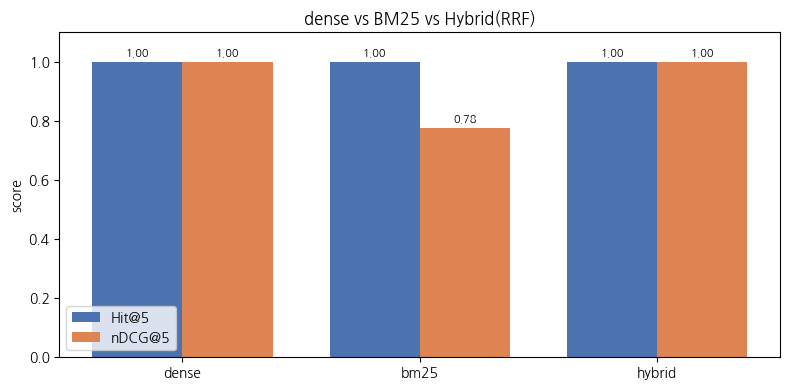

In [9]:
import matplotlib.pyplot as plt

methods = [("dense", dense_rank), ("bm25", bm25_rank), ("hybrid", hybrid_rank)]
hit_scores, ndcg_scores, names = [], [], []
for name, fn in methods:
    h, n = evaluate(fn, k=5)
    names.append(name); hit_scores.append(h); ndcg_scores.append(n)

x = np.arange(len(names)); w = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, hit_scores,  w, label="Hit@5",  color="#4C72B0")
plt.bar(x + w/2, ndcg_scores, w, label="nDCG@5", color="#DD8452")
plt.xticks(x, names); plt.ylim(0, 1.1); plt.ylabel("score")
plt.title("dense vs BM25 vs Hybrid(RRF)"); plt.legend()
for i, (h, n) in enumerate(zip(hit_scores, ndcg_scores)):
    plt.text(i - w/2, h + 0.02, f"{h:.2f}", ha="center", fontsize=8)
    plt.text(i + w/2, n + 0.02, f"{n:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

## 쿼리 유형별 분해 (키워드형 vs 의미형)
- EVALSET을 유형으로 나눠 **dense는 의미형에서, BM25는 키워드형에서** 강한지 확인

### 질문 유형별로 쪼개 보기(단어형 vs 의미형)
- 질문을 단어형/의미형으로 나눠 어느 검색이 어디서 강한지 봄
- **그래프 읽는 법**: BM25는 **단어형**(keyword)에서, dense는 **의미형**(semantic)에서 높고, Hybrid는 양쪽을 모두 흡수함


dense    keyword=1.00  semantic=1.00
bm25     keyword=1.00  semantic=1.00
hybrid   keyword=1.00  semantic=1.00


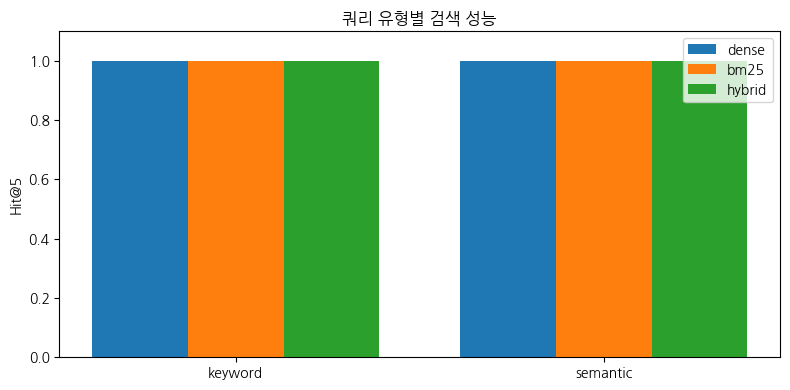

In [10]:
# 쿼리 유형 라벨 부여 (앞 2개=키워드형, 뒤 3개=의미형)
TYPES = ["keyword", "keyword", "semantic", "semantic", "semantic"]

def evaluate_by_type(rank_fn, k=5):
    agg = {"keyword": [], "semantic": []}
    for e, t in zip(EVALSET, TYPES):
        agg[t].append(hit_at_k(rank_fn(e["q"], k), e["gold"], k))
    return {t: (sum(v)/len(v) if v else 0.0) for t, v in agg.items()}

rows = {}
for name, fn in methods:
    rows[name] = evaluate_by_type(fn, 5)
    print(f"{name:7s}  keyword={rows[name]['keyword']:.2f}  semantic={rows[name]['semantic']:.2f}")

labels = ["keyword", "semantic"]; x = np.arange(len(labels)); w = 0.26
plt.figure(figsize=(8, 4))
for i, (name, _) in enumerate(methods):
    vals = [rows[name]["keyword"], rows[name]["semantic"]]
    plt.bar(x + (i-1)*w, vals, w, label=name)
plt.xticks(x, labels); plt.ylim(0, 1.1); plt.ylabel("Hit@5")
plt.title("쿼리 유형별 검색 성능"); plt.legend(); plt.tight_layout(); plt.show()

> 해석: BM25는 키워드형에서, dense는 의미형에서 유리. Hybrid는 양쪽을 모두 흡수

## RRF k값 스윕
- `rrf_k`(융합 상수)를 바꾸며 Hybrid 성능 곡선을 그림
- k가 작으면 상위 순위에 민감, 크면 평탄해짐

### rrf_k 값을 죽 바꿔 곡선 보기
- 융합 상수 rrf_k를 여러 값으로 바꿔 Hybrid 성능 곡선을 그림
- **어느 값이 좋은지는 데이터마다 다르니 직접 재본다**는 게 교훈


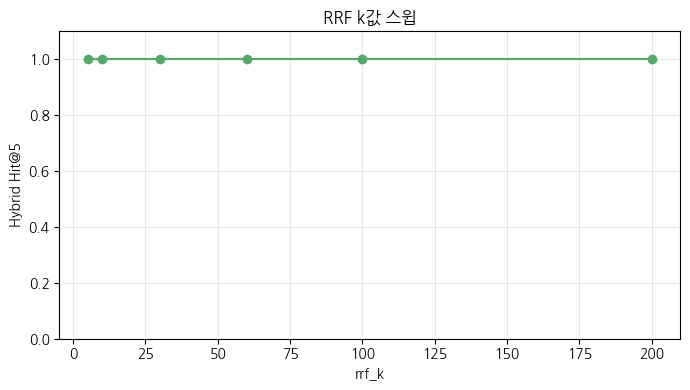

rrf_k별 Hit@5: {5: 1.0, 10: 1.0, 30: 1.0, 60: 1.0, 100: 1.0, 200: 1.0}


In [11]:
rrf_ks = [5, 10, 30, 60, 100, 200]
sweep_hit = []
for rk in rrf_ks:
    fn = lambda q, k=5, _rk=rk: hybrid_rank(q, k, rrf_k=_rk)
    h, _ = evaluate(fn, k=5)
    sweep_hit.append(h)

plt.figure(figsize=(7, 4))
plt.plot(rrf_ks, sweep_hit, "o-", color="#55A868")
plt.xlabel("rrf_k"); plt.ylabel("Hybrid Hit@5"); plt.ylim(0, 1.1)
plt.title("RRF k값 스윕"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("rrf_k별 Hit@5:", {rk: round(h, 3) for rk, h in zip(rrf_ks, sweep_hit)})

## 가중 RRF (dense/sparse 가중치 스윕)
- dense와 sparse 기여도에 가중치를 두는 **가중 RRF**를 구현하고, `alpha`(dense 비중)를 스윕

### 가중 RRF(의미:단어 비중 조절)
- dense와 sparse에 **가중치**(alpha)를 줘 어느 쪽을 더 믿을지 조절
- `alpha=1`이면 의미만, `alpha=0`이면 단어만, 중간이면 혼합
- **그래프 읽는 법**: 보통 양 극단(0 또는 1)보다 **중간 어디쯤에서 가장 높은 점**이 생김


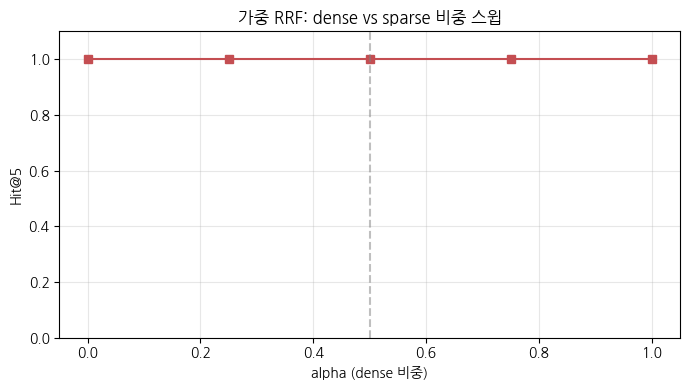

alpha별 Hit@5: {0.0: 1.0, 0.25: 1.0, 0.5: 1.0, 0.75: 1.0, 1.0: 1.0}


In [12]:
def weighted_rrf(query, k=5, rrf_k=60, alpha=0.5):
    """alpha=dense 가중, (1-alpha)=sparse 가중."""
    d = dense_rank(query, k); b = bm25_rank(query, k)
    scores = {}
    for rank, did in enumerate(d, 1):
        scores[did] = scores.get(did, 0.0) + alpha * 1.0/(rrf_k + rank)
    for rank, did in enumerate(b, 1):
        scores[did] = scores.get(did, 0.0) + (1-alpha) * 1.0/(rrf_k + rank)
    return [d for d, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]]

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
alpha_hit = []
for a in alphas:
    fn = lambda q, k=5, _a=a: weighted_rrf(q, k, alpha=_a)
    h, _ = evaluate(fn, 5)
    alpha_hit.append(h)

plt.figure(figsize=(7, 4))
plt.plot(alphas, alpha_hit, "s-", color="#C44E52")
plt.xlabel("alpha (dense 비중)"); plt.ylabel("Hit@5"); plt.ylim(0, 1.1)
plt.title("가중 RRF: dense vs sparse 비중 스윕")
plt.axvline(0.5, ls="--", c="gray", alpha=0.5)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("alpha별 Hit@5:", {a: round(h, 3) for a, h in zip(alphas, alpha_hit)})

> 해석: alpha=0이면 BM25-only, 1이면 dense-only. 중간(혼합)에서 보통 최고점이 형성

## 직접 해보기: 나만의 쿼리 추가
- 키워드형/의미형 쿼리를 1개씩 EVALSET에 추가하고 세 방식 중 어느 게 이기는지 예측한 뒤 측정해 보기

In [13]:
# 🔧 직접 해보기 ②: 나만의 질문을 추가해 어느 검색이 이기는지 예측→측정해 보세요.
# 힌트: 단어형(정확한 고유명사)과 의미형(말바꿈) 중 하나를 골라 질문을 적고, 정답 문서 번호(gold)를 DOCS에서 찾아 넣습니다.
#       DOCS 목록을 보고 0번부터 세어 정답 문서의 번호를 적으세요.
MY = [{"q": "전기차 부품 만드는 회사", "gold": 2}]   # <- 질문과 정답 번호를 바꿔보세요
for name, fn in methods:
    hit = hit_at_k(fn(MY[0]['q'], 5), MY[0]['gold'], 5)
    print(f'{name:7s} Hit@5={hit}')


dense   Hit@5=1.0
bm25    Hit@5=1.0
hybrid  Hit@5=1.0


## 검증: 가중 RRF & 스윕

### 가중 RRF 설계가 맞는지 검증
- `alpha=0`은 BM25-only와, `alpha=1`은 dense-only와 같은 후보를 내는지 자동 확인 (설계 정합성)
- `통과`면 정상


In [14]:
# 가중 RRF의 양 극단이 단일 방식과 일치하는지(설계 정합)
wa0 = set(weighted_rrf(EVALSET[0]["q"], k=5, alpha=0.0))
wb0 = set(bm25_rank(EVALSET[0]["q"], 5))
wa1 = set(weighted_rrf(EVALSET[0]["q"], k=5, alpha=1.0))
wd1 = set(dense_rank(EVALSET[0]["q"], 5))
assert wa0 == wb0, "alpha=0은 BM25-only와 같은 후보집합이어야 함"
assert wa1 == wd1, "alpha=1은 dense-only와 같은 후보집합이어야 함"
# 스윕 결과가 모두 0~1
assert all(0.0 <= h <= 1.0 for h in sweep_hit + alpha_hit)
print("심화(가중 RRF/스윕) 검증 통과")

심화(가중 RRF/스윕) 검증 통과


## 확장과제
- **가중 RRF 최적 alpha**: 위 스윕에서 도메인 최적 alpha를 찾고 왜 그 값인지 설명
- **SPLADE(개념)**: 학습된 sparse 표현으로 BM25를 대체하는 방법(소개). dense+SPLADE도 Hybrid 가능
- **한국어 토크나이징 주의**: 공백 분리는 거칠어서 `kiwipiepy`/형태소 분석기로 BM25 토큰을 개선하면 sparse 성능이 크게 오름
- 형태소 토크나이저로 BM25를 다시 만들어 키워드형 Hit가 오르는지 측정

> 이 노트북의 `DOCS`, `embed`, `findex`, `hybrid_rank`는 lab4(Reranking) 입력으로 재사용
> 쿼리 재작성·HyDE로 검색을 더 끌어올리는 심화는 **lab3b_query_rewrite_hyde.ipynb**로 이어짐

---
# 쿼리 재작성 & HyDE (검색 심화)

## 학습목표
- 사용자의 거친/짧은 질문을 Claude로 **재작성**(query rewrite)해 검색 적중을 높임
- **Multi-query 확장**(한 질문 → 여러 변형) + 결과 융합으로 recall을 높임
- **HyDE**(Hypothetical Document Embeddings): 질문으로 가상의 답변 문서를 생성해 그 임베딩으로 검색
- 네 방식(원쿼리/재작성/멀티쿼리/HyDE)을 **정량 비교**

## 사전개념
- 짧은 키워드 질문은 임베딩이 빈약해 의미검색이 약하다 → **질문을 풍부하게** 만들면 검색이 강화
- **HyDE**: '질문→가상 답변 생성→그 답변을 임베딩'. 답변은 문서와 어휘/구조가 비슷해 매칭이 잘 됨 (틀려도 OK, 임베딩만 쓴다)

> 비-Claude: sentence-transformers(임베딩), faiss(검색), rank_bm25(sparse). 재작성·HyDE 생성은 **Claude**

## 용어 미니 사전 (쿼리 재작성·HyDE 편)
- 검색이 잘 안 될 때, **문서를 손대는 대신 '질문'을 손봐서** 적중을 높이는 기법들

| 용어 | 한 줄 뜻 |
|---|---|
| **Query rewrite(쿼리 재작성)** | 짧고 거친 질문을 완전한 문장으로 다듬어 검색에 유리하게 |
| **Multi-query(멀티쿼리)** | 한 질문을 여러 표현으로 바꿔 각각 검색 후 합치기(놓침 보완) |
| **HyDE** | 질문에 대한 *그럴듯한 가상 답변*을 LLM이 지어내고, 그 답변으로 검색하기 |
| **recall(재현율)** | 정답을 *놓치지 않고* 얼마나 데려오는지 |
| **MRR** | 정답이 *몇 번째*로 나왔는지의 역수(위에 빨리 나올수록↑) |

> 핵심 메시지: 질문이 짧고 거칠면 검색이 약함   **질문을 풍부하게(재작성/HyDE) 만들면** 같은 문서·같은 검색기로도 더 잘 찾음  
HyDE의 가상 답변은 틀려도 괜찮다 — 임베딩(어휘·구조)만 쓰기 때문


## 코퍼스 + dense 검색
- 문서는 서술형(긴 문장), 질문은 짧은/구어체로 둬서 재작성·HyDE 효과가 드러나게 함

### 문서·의미검색 준비
- 검색 대상 문서(서술형 긴 문장)와 의미검색기(임베딩+FAISS)를 만듦
- 질문은 일부러 짧고 구어체로 둬서, 재작성/HyDE 효과가 잘 보이게 함


In [15]:
import numpy as np, faiss, math
from sentence_transformers import SentenceTransformer

DOCS = [
    "노바테크의 2023년 연결 매출은 1조 2천억 원이며 영업이익은 1,800억 원을 기록했다.",
    "노바테크의 최고경영자 김하늘은 2021년 취임 이후 AI 가속기 사업을 적극 확장했다.",
    "그린모빌리티는 고밀도 리튬인산철 배터리를 양산하는 전기차 부품 제조 기업이다.",
    "오션로지스틱스는 친환경 연료 선박을 도입해 2023년 탄소배출을 전년 대비 12% 줄였다.",
    "퀀텀칩은 데이터센터용 AI 가속 칩 시장에서 노바테크와 점유율 경쟁을 벌인다.",
    "정밀소재(PrecisionMat)는 노바테크와 퀀텀칩 모두에 핵심 소재를 납품하는 공통 공급사다.",
    "노바소프트는 노바테크가 지분을 보유한 클라우드 소프트웨어 자회사다.",
    "그린모빌리티의 최고재무책임자 박서준은 2024년 기업공개(IPO)를 준비하고 있다.",
    "노바테크 이사회는 2023 회계연도에 주당 800원의 현금배당을 의결했다.",
    "그린모빌리티는 노바테크로부터 2022년 500억 원 규모의 전략적 지분 투자를 유치했다.",
]
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
def embed(t): return np.array(embedder.encode(t, normalize_embeddings=True), dtype="float32")
DOC_EMB = embed(DOCS); findex = faiss.IndexFlatIP(DOC_EMB.shape[1]); findex.add(DOC_EMB)

def dense_search(query_text, k=5):
    _, idx = findex.search(embed([query_text]), min(k, len(DOCS)))
    return list(idx[0])

def dense_search_vec(vec, k=5):
    _, idx = findex.search(vec, min(k, len(DOCS)))
    return list(idx[0])
print("코퍼스/인덱스 준비 완료, 문서", len(DOCS), "건")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

코퍼스/인덱스 준비 완료, 문서 10 건


## 평가셋 (짧고 거친 질문)
- 구어체/축약/오타성 질문을 둬서, 원쿼리 검색이 종종 정답을 놓치게 만듦

### 일부러 '거친 질문'으로 시험지 만들기
- "노바 배터리 투자한 데 어디임?"처럼 **축약·구어체·짧은** 질문을 모름
- 이런 질문은 원본 그대로는 검색이 잘 안 돼서, 개선 기법의 효과를 보기 좋음


In [16]:
EVALSET = [
    {"q": "노바 배터리 투자한 데 어디임?", "gold": 9},   # 구어체+축약 (그린모빌리티 투자=노바테크)
    {"q": "IPO 한다는 사람", "gold": 7},                 # 매우 짧음 (박서준)
    {"q": "공통 부품 납품 회사", "gold": 5},              # 키워드 흩어짐 (정밀소재)
    {"q": "탄소 줄인 배 회사", "gold": 3},               # 구어체 (오션로지스틱스)
    {"q": "노바 배당 얼마", "gold": 8},                   # 축약 (800원)
    {"q": "데이터센터 칩 경쟁사", "gold": 4},             # (퀀텀칩)
]

def hit_at_k(ranked, gold, k): return 1.0 if gold in ranked[:k] else 0.0
def mrr(ranked, gold):
    for r, d in enumerate(ranked, 1):
        if d == gold: return 1.0/r
    return 0.0
print("질문", len(EVALSET), "건 (짧고 거친 형태)")

질문 6 건 (짧고 거친 형태)


## 개념 복습: 왜 쿼리를 손보나
- 검색은 **질문 임베딩 ↔ 문서 임베딩**의 거리
- 질문이 짧고 거칠면 임베딩이 빈약해 정답 문서와 멀어짐
- **Query rewrite**: 질문을 문어체·완전문장으로 다듬어 어휘를 문서와 맞춤
- **Multi-query**: 한 질문을 여러 각도로 바꿔 각각 검색 후 **RRF 융합**(놓침 보완)
- **HyDE**: 질문에 대한 그럴듯한 답변 문서를 LLM이 지어내고, 그 텍스트 임베딩으로 검색. 답변은 실제 문서와 어휘·구조가 닮아 매칭률↑

## 쿼리 재작성 (Query Rewrite)
- Claude가 거친 질문을 검색 친화적 완전문장으로 다듬기

### 질문 다듬기(재작성)
- Claude가 거친 질문을 **검색하기 좋은 완전한 문장**으로 고쳐 씀
- **출력 읽는 법**: '원본'과 '재작성'을 비교해 보세요. 축약어가 풀리고 문장이 또렷해졌을 것


In [17]:
def ask_claude(query, system, max_tokens=200):
    response = client.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[
            {"role": "user", "content": query}
        ]
    )
    return response.content[0].text

def rewrite_query(q):
    sys = ("사용자 질문을 벡터 검색에 적합하도록 군더더기 없이 완전한 문장으로 다시 써라. "
           "고유명사를 풀어주고 한 문장으로. 설명 없이 재작성된 질문만 출력.")
    return ask_claude(q, system=sys, max_tokens=100).strip()

for e in EVALSET[:3]:
    print(f"원본 : {e['q']}")
    print(f"재작성: {rewrite_query(e['q'])}\n")

원본 : 노바 배터리 투자한 데 어디임?
재작성: 노바 배터리에 투자한 투자사 또는 투자 기관은 어디인가?

원본 : IPO 한다는 사람
재작성: IPO(기업공개)를 진행한다고 밝힌 사람은 누구인가?

원본 : 공통 부품 납품 회사
재작성: 여러 제품에 공통으로 사용되는 부품을 납품하는 회사는 어디인가요?



## Multi-query 확장 + RRF 융합
- 한 질문을 여러 변형으로 만들고 각 변형의 검색 결과를 RRF로 합침

### 질문을 여러 갈래로 늘리기(멀티쿼리)
- 한 질문을 **여러 표현으로** 바꿔 각각 검색한 뒤 RRF로 합침
- 한 표현이 놓친 정답을 다른 표현이 건지는 효과(놓침 보완)
- **출력 읽는 법**: '변형들'에 비슷하지만 표현이 다른 질문들이 나오고, 그걸 합친 검색 결과 번호가 출력됨


In [18]:
def multi_query(q, n=3):
    sys = (f"다음 질문을 의미는 같지만 표현이 다른 {n}개의 검색 질의로 바꿔라. "
           "각 줄에 하나씩, 번호나 설명 없이 질의만.")
    out = ask_claude(q, system=sys, max_tokens=200)
    variants = [l.strip(" -0123456789.") for l in out.split("\n") if l.strip()]
    return ([q] + variants)[:n+1]

def rrf_fuse(rankings, rrf_k=60, top=5):
    s = {}
    for r in rankings:
        for rank, d in enumerate(r, 1): s[d] = s.get(d, 0.0) + 1.0/(rrf_k + rank)
    return [d for d, _ in sorted(s.items(), key=lambda x: x[1], reverse=True)[:top]]

def multiquery_search(q, k=5):
    qs = multi_query(q, n=3)
    rankings = [dense_search(v, k=k) for v in qs]
    return rrf_fuse(rankings, top=k)

demo = EVALSET[0]
print("변형들:", multi_query(demo["q"], 3))
print("멀티쿼리 검색 결과 id:", multiquery_search(demo["q"]))

변형들: ['노바 배터리 투자한 데 어디임?', '노바 배터리에 투자한 곳은 어디인가요?', '노바 배터리 투자사가 어디어디 있나요?', '노바 배터리에 투자한 기관이나 회사가 어디입니까?']
멀티쿼리 검색 결과 id: [np.int64(2), np.int64(9), np.int64(3), np.int64(6), np.int64(7)]


## HyDE (가상 답변 문서 임베딩)
- 질문에 대한 그럴듯한 답변 한 문단을 Claude가 생성하고, 그 텍스트 임베딩으로 검색
- 사실 여부는 중요치 않다 — 어휘·구조가 문서와 닮게 만드는 것이 목적

### HyDE: 가상 답변으로 검색하기
- Claude가 질문에 대한 **그럴듯한 답변 문단**을 지어내고, 그 답변을 임베딩해 검색
- 답변은 실제 문서와 어휘·구조가 닮아 매칭이 잘 됨   (사실 여부는 안 따집니다 — 임베딩만 쓰니까요)
- **출력 읽는 법**: 'HyDE 가상 답변'이 그럴듯한 문장이고, 그걸로 검색한 결과 번호가 정답을 잘 포함하는지 보기


In [19]:
def hyde_doc(q):
    sys = ("아래 질문에 대해 사실처럼 보이는 1~2문장의 가상 답변을 작성하라. "
           "회사/금융 도메인 문체로. 모른다고 하지 말고 그럴듯하게.")
    return ask_claude(q, system=sys, max_tokens=120)

def hyde_search(q, k=5):
    pseudo = hyde_doc(q)
    return dense_search_vec(embed([pseudo]), k=k)

print("HyDE 가상 답변 예:")
print(" ", hyde_doc(demo["q"]))
print("HyDE 검색 결과 id:", hyde_search(demo["q"]))

HyDE 가상 답변 예:
  노바 배터리(Nova Battery)는 최근 한화인베스트먼트 및 KDB산업은행 주도의 컨소시엄으로부터 시리즈 B 라운드 투자를 유치하였으며, 추가적으로 LG에너지솔루션 벤처스가 전략적 투자자(SI)로 참여한 것으로 파악됩니
HyDE 검색 결과 id: [np.int64(2), np.int64(9), np.int64(3), np.int64(0), np.int64(8)]


## 네 방식 정량 비교
- 원쿼리 / 재작성 / 멀티쿼리 / HyDE를 같은 평가셋으로 Hit@5·MRR 비교
- 예상 호출: 재작성·멀티쿼리·HyDE 각각 질문 수만큼 Claude 호출(소규모)

### 네 방식 성적 비교
- **원쿼리 / 재작성 / 멀티쿼리 / HyDE** 를 같은 시험지로 Hit@5·MRR 비교 (Claude를 질문 수만큼 부르므로 약간 시간이 걸림)
- **출력 읽는 법**: 거친 질문에선 보통 **재작성·HyDE가 원쿼리보다 높게** 나오는 경향이고, 최적은 데이터마다 다름


In [20]:
def baseline_search(q, k=5): return dense_search(q, k=k)
def rewrite_search(q, k=5):  return dense_search(rewrite_query(q), k=k)

methods = {
    "original":   baseline_search,
    "rewrite":    rewrite_search,
    "multiquery": multiquery_search,
    "HyDE":       hyde_search,
}

summary = {}
for name, fn in methods.items():
    hits, mrrs = [], []
    for e in EVALSET:
        ranked = fn(e["q"], k=5)
        hits.append(hit_at_k(ranked, e["gold"], 5)); mrrs.append(mrr(ranked, e["gold"]))
    summary[name] = {"Hit@5": sum(hits)/len(hits), "MRR": sum(mrrs)/len(mrrs)}
    print(f"{name:11s} Hit@5={summary[name]['Hit@5']:.3f}  MRR={summary[name]['MRR']:.3f}")

original    Hit@5=1.000  MRR=0.778
rewrite     Hit@5=1.000  MRR=0.833
multiquery  Hit@5=1.000  MRR=0.806
HyDE        Hit@5=1.000  MRR=0.917


### 네 방식 막대그래프 비교
- 네 방식의 Hit@5·MRR을 막대로 보기
- **그래프 읽는 법**: 원쿼리(original)보다 막대가 높은 방식이 이 데이터에서 검색을 끌어올린 것

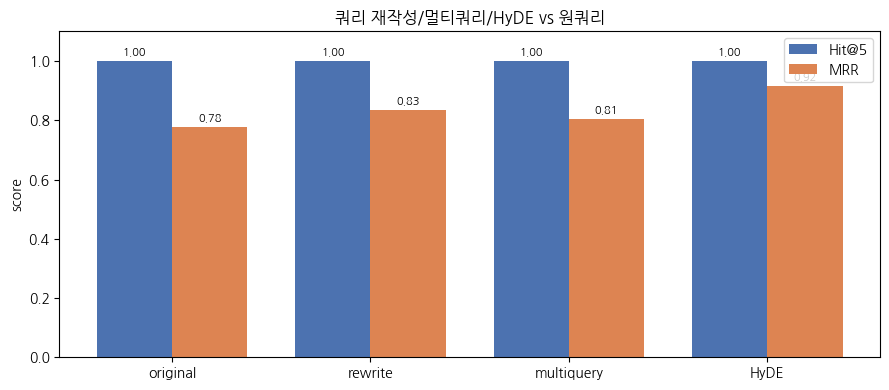

In [21]:
import matplotlib.pyplot as plt

names = list(summary.keys())
hit_v = [summary[n]["Hit@5"] for n in names]
mrr_v = [summary[n]["MRR"] for n in names]
x = np.arange(len(names)); w = 0.38
plt.figure(figsize=(9, 4))
plt.bar(x - w/2, hit_v, w, label="Hit@5", color="#4C72B0")
plt.bar(x + w/2, mrr_v, w, label="MRR",   color="#DD8452")
plt.xticks(x, names); plt.ylim(0, 1.1); plt.ylabel("score")
plt.title("쿼리 재작성/멀티쿼리/HyDE vs 원쿼리")
plt.legend()
for i, (h, m) in enumerate(zip(hit_v, mrr_v)):
    plt.text(i - w/2, h + 0.02, f"{h:.2f}", ha="center", fontsize=8)
    plt.text(i + w/2, m + 0.02, f"{m:.2f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

> 해석: 짧고 거친 질문일수록 재작성/HyDE가 원쿼리보다 검색을 끌어올리는 경향  
멀티쿼리는 recall(놓침 보완)에 강함  
도메인마다 최적이 다르니 측정해서 고름

## 직접 해보기: 재작성 + 멀티쿼리 결합
- 재작성한 질문을 다시 멀티쿼리로 확장하는 파이프라인을 만들어 Hit@5가 더 오르는지 측정하기

In [22]:
# 🔧 직접 해보기 ①: '재작성 → 멀티쿼리'를 이어 붙이면 더 좋아질까요?
# 힌트: 재작성한 질문을 다시 멀티쿼리로 늘려 각각 검색 후 합칩니다(아래는 완성형).
def rewrite_then_multi(q, k=5):
    rq = rewrite_query(q)                          # 1) 먼저 다듬고
    qs = multi_query(rq, n=3)                      # 2) 여러 갈래로 늘리고
    rankings = [dense_search(v, k) for v in qs]    # 3) 각각 검색
    return rrf_fuse(rankings, top=k)               # 4) 합치기
scores = [hit_at_k(rewrite_then_multi(e['q']), e['gold'], 5) for e in EVALSET]
print(f'재작성+멀티쿼리 Hit@5 = {sum(scores)/len(scores):.3f}  (위 표의 rewrite/multiquery와 비교해 보세요)')


재작성+멀티쿼리 Hit@5 = 1.000  (위 표의 rewrite/multiquery와 비교해 보세요)


## 직접 해보기: HyDE 다중 가설 융합
- HyDE 가상 답변을 1개가 아니라 3개 생성해 각 임베딩 검색을 RRF로 융합하면 더 안정적인지 실험하기

In [23]:
# 🔧 직접 해보기 ②: HyDE 가상 답변을 여러 개 만들어 합치면 더 안정적일까요?
# 힌트: hyde_doc을 3번 불러 각 임베딩으로 검색한 뒤 rrf_fuse로 합칩니다(아래는 완성형).
def hyde_multi_search(q, k=5, n=3):
    rankings = [dense_search_vec(embed([hyde_doc(q)]), k=k) for _ in range(n)]
    return rrf_fuse(rankings, top=k)
scores = [hit_at_k(hyde_multi_search(e['q']), e['gold'], 5) for e in EVALSET]
print(f'HyDE(3개 융합) Hit@5 = {sum(scores)/len(scores):.3f}  (단일 HyDE와 비교)')


HyDE(3개 융합) Hit@5 = 1.000  (단일 HyDE와 비교)


## 검증

### 네 방식이 정상 동작하는지 검증
- 각 방식이 올바른 형태의 결과를 내는지, 재작성·HyDE 생성이 비어있지 않은지, 점수가 0~1 범위인지 확인
- `통과`면 정상


In [24]:
# 1) 각 방식이 정상 id 리스트 반환
for name, fn in methods.items():
    out = fn(EVALSET[0]["q"], k=5)
    assert isinstance(out, list) and all(isinstance(i, (int, np.integer)) for i in out), name
# 2) 재작성 결과가 비어있지 않음
assert len(rewrite_query("노바 배당 얼마")) > 0
# 3) HyDE 가상 문서가 생성됨
assert len(hyde_doc("IPO 한다는 사람")) > 0
# 4) 모든 지표 0~1
for name, m in summary.items():
    assert 0.0 <= m["Hit@5"] <= 1.0 and 0.0 <= m["MRR"] <= 1.0, name
print("쿼리 재작성/HyDE 검증 통과")

쿼리 재작성/HyDE 검증 통과


## 확장과제
- **HyDE + Hybrid**: HyDE 임베딩 검색을 BM25와 RRF 융합해 봄 (가상답변은 키워드도 늘림)
- **재작성 비용/지연**: 모든 질의에 LLM 재작성을 붙이면 지연·비용↑ → '짧은 질문만 재작성'하는 라우팅
- **step-back prompting**: 구체 질문을 한 단계 일반화한 질문으로 바꿔 배경 문서를 먼저 검색
- 재작성/HyDE로 끌어올린 검색 결과를 cross-encoder 리랭크에 넘겨 2단계로 결합